# OBM vs Kelly Bankroll Management

Value iteration converges to a stationary Certainty-Equivalent Winrate (CEW) for each bankroll level. The CEW is the per-period dollar amount that makes the player indifferent between accepting it with certainty and playing optimally.

The **Kelly benchmark** (log utility, no iteration) is compared against the fully optimal **OBM** solution.

## Imports and style

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIG_DIR = Path("../quarto/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── clean matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
})

## Parameters

In [2]:
from brm import (
    gen_xgrid,
    build_sampling_df,
    kelly_cew,
    solve_obm,
    extract_threshold,
)

# ── game parameters  (buyin, winrate, std) ──────────────────────────────────
game_choices = {
    0: (0,    5,   0),   # outside option: work ($5/hr, no variance)
    1: (100,  10, 100),  # 1/2 NL
    2: (200,  15, 200),  # 2/5 NL
    3: (500,  20, 500),  # 5/10 NL
}

GAME_LABELS = {
    0: "work  ($5/hr)",
    1: "1/2   ($10/hr)",
    2: "2/5   ($15/hr)",
    3: "5/10  ($20/hr)",
}
GAME_COLORS = {0: "#888888", 1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

# ── grid ────────────────────────────────────────────────────────────────────
gridsize = 100
xmax     = 500_000
xmin     = game_choices[1][0]   # smallest buyin = 100
N        = len(game_choices)

xgrid = gen_xgrid(xmax, xmin=xmin, gridsize=gridsize)
print(f"Grid: {gridsize} points from ${xgrid[0]:,.0f} to ${xgrid[-1]:,.0f}")

Grid: 100 points from $100 to $500,000


## Solve: OBM and Kelly

In [3]:
# ── Kelly benchmark (closed-form, one-shot) ─────────────────────────────────
sampling_df         = build_sampling_df(game_choices, xgrid)
CEW_choices_kelly, CEW_kelly = kelly_cew(sampling_df, xgrid)

# ── OBM value iteration ─────────────────────────────────────────────────────
CEW_array, CEW_choices_obm, vf = solve_obm(game_choices, xgrid, tol=1e-2)

n_iter = CEW_array.shape[1] - 1   # column 0 = Kelly init; columns 1..k = OBM
print(f"OBM converged in {n_iter} iterations")

# ── Convergence distance from successive CEW columns ────────────────────────
# CEW_array[:,k] = max-over-games CEW at iteration k
# Convergence distance ≈ max|CEW_k - CEW_{k-1}| / max(CEW_{k-1})
conv_dists = np.array([
    np.max(np.abs(CEW_array[:, k] - CEW_array[:, k - 1])) / np.max(CEW_array[:, k - 1])
    for k in range(1, CEW_array.shape[1])
])

# ── Thresholds ───────────────────────────────────────────────────────────────
thresh_kelly = {n: extract_threshold(n, CEW_choices_kelly, xgrid, game_choices)
                for n in range(1, N)}
thresh_obm   = {n: extract_threshold(n, CEW_choices_obm,   xgrid, game_choices)
                for n in range(1, N)}

print()
print(f"{'Transition':<16}  {'Kelly':>10}  {'OBM':>10}  {'Δ (OBM−Kelly)':>14}")
print("-" * 56)
for n in range(1, N):
    delta = thresh_obm[n] - thresh_kelly[n]
    print(f"  game {n-1} → game {n}     ${thresh_kelly[n]:>8,.0f}  ${thresh_obm[n]:>8,.0f}  ${delta:>+12,.0f}")

OBM converged in 47 iterations

Transition             Kelly         OBM   Δ (OBM−Kelly)
--------------------------------------------------------
  game 0 → game 1     $     999  $     546  $        -453
  game 1 → game 2     $   2,994  $   2,725  $        -270
  game 2 → game 3     $  20,917  $  18,982  $      -1,935


## Convergence

Convergence is measured as the max absolute change in CEW across grid points, normalised by the current max CEW. The plot starts from iteration 2 (iteration 1 is the large jump from the Kelly initialisation to the first OBM update).

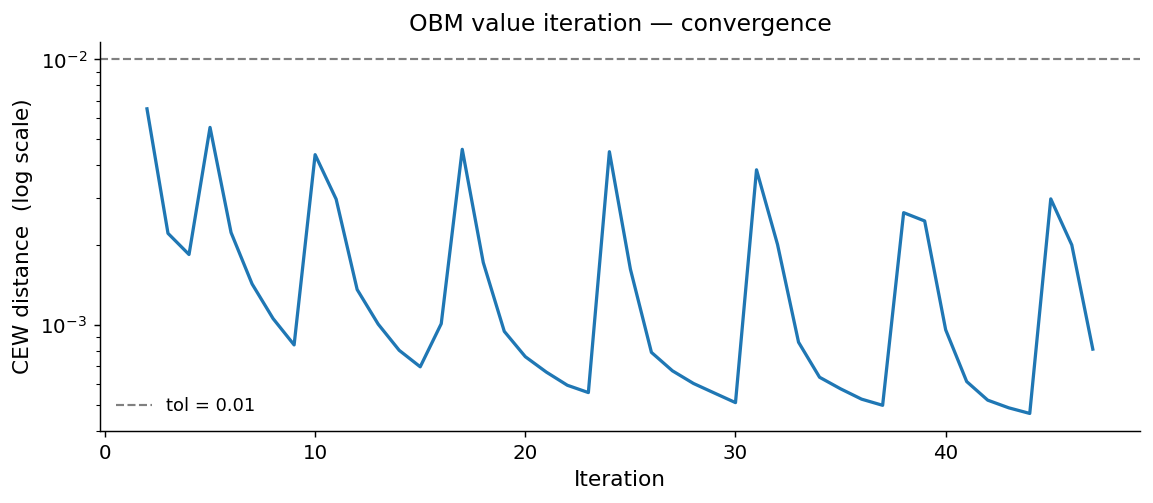

In [4]:
# Skip the very first distance (Kelly → OBM iter 1) which is always large
iters_plot = np.arange(2, len(conv_dists) + 1)
dists_plot = conv_dists[1:]

fig, ax = plt.subplots()
ax.plot(iters_plot, dists_plot, color="#1f77b4", lw=1.8)
ax.axhline(0.01, ls="--", color="gray", lw=1.2, label="tol = 0.01")
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("CEW distance  (log scale)")
ax.set_title("OBM value iteration — convergence")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "obm_convergence.png", bbox_inches="tight")
plt.show()

## OBM Certainty-Equivalent Winrate

Curves show the per-hour CEW for each game as a function of bankroll. Dotted horizontals mark the true EV for each game. Dashed verticals mark the move-up thresholds. The optimal game at any bankroll is the one with the highest CEW.

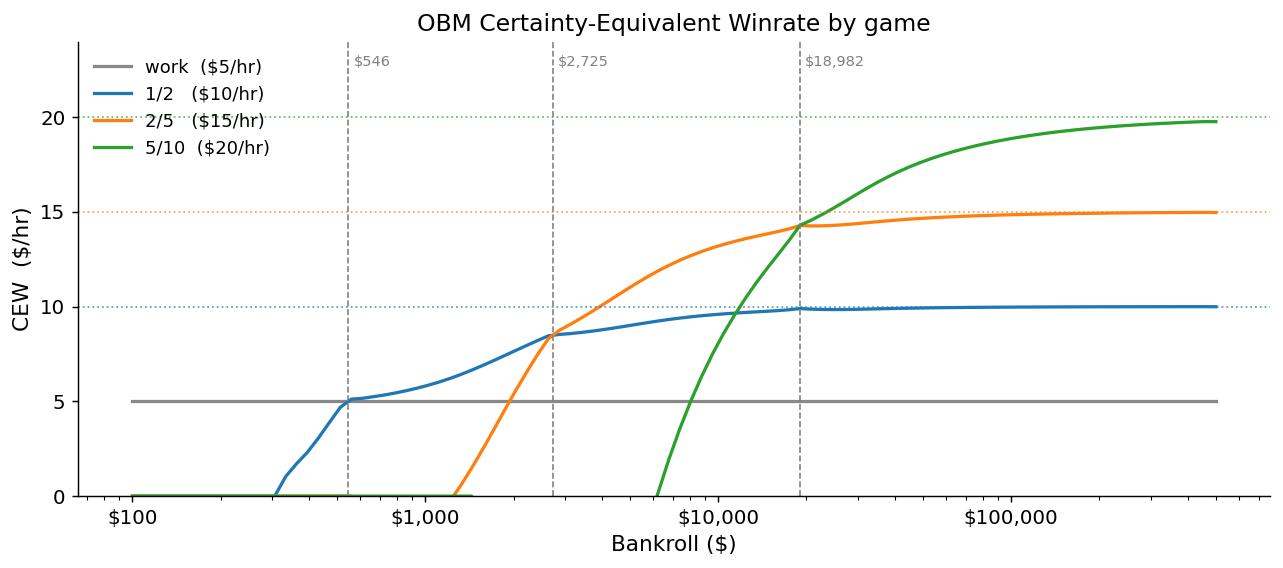

In [5]:
def _cew_plot(CEW_choices, thresholds, game_choices, title, fname):
    """Plot CEW curves by game with threshold verticals and true-EV horizontals."""
    fig, ax = plt.subplots(figsize=(10, 4.5))

    for n in range(N):
        sub = CEW_choices[CEW_choices["n"] == n].sort_values("x")
        ax.plot(sub["x"], sub["CEW"],
                color=GAME_COLORS[n], lw=1.8, label=GAME_LABELS[n])

    # true EV horizontals (dotted)
    for n in range(1, N):
        ev = game_choices[n][1]
        ax.axhline(ev, ls=":", color=GAME_COLORS[n], lw=1.0, alpha=0.7)

    # threshold verticals (dashed gray)
    for n, thresh in thresholds.items():
        ax.axvline(thresh, ls="--", color="gray", lw=0.9)
        ax.text(thresh * 1.04, ax.get_ylim()[1] * 0.97,
                f"${thresh:,.0f}", fontsize=8, color="gray", va="top")

    ax.set_xscale("log")
    _, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Bankroll ($)")
    ax.set_ylabel("CEW  ($/hr)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()


_cew_plot(
    CEW_choices_obm, thresh_obm, game_choices,
    title="OBM Certainty-Equivalent Winrate by game",
    fname="obm_cew.png",
)

## Kelly Certainty-Equivalent Winrate

Same layout as above, but using one-shot Kelly (log utility). Kelly thresholds are systematically higher than OBM thresholds because Kelly does not account for the compounding optionality of moving up in stakes.

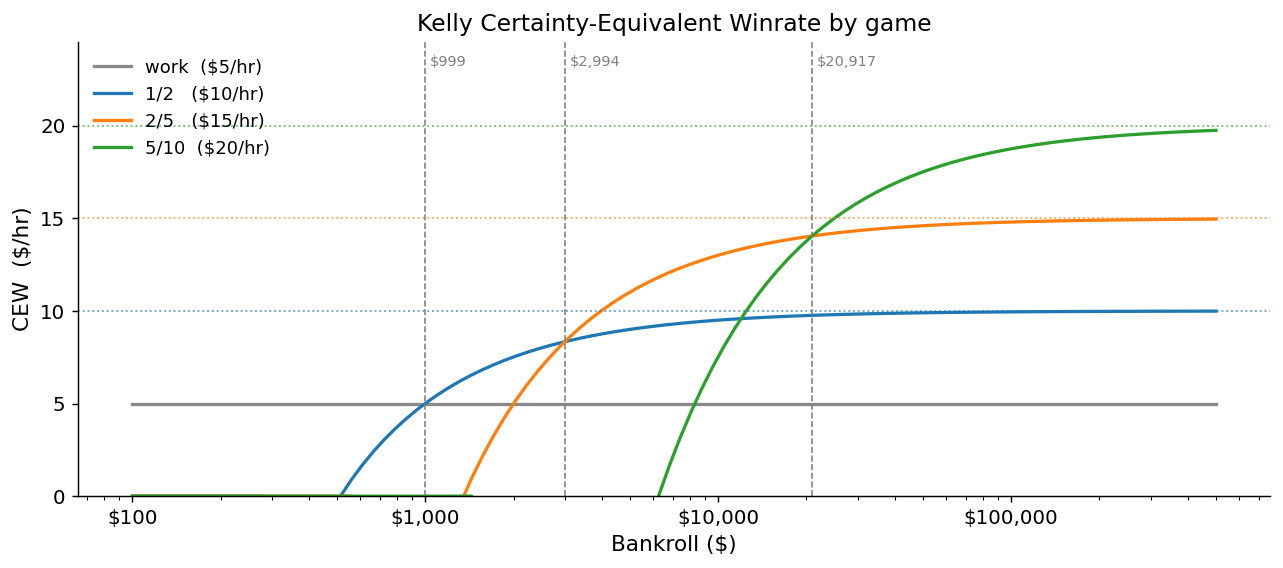

In [6]:
_cew_plot(
    CEW_choices_kelly, thresh_kelly, game_choices,
    title="Kelly Certainty-Equivalent Winrate by game",
    fname="kelly_cew.png",
)

## Threshold comparison: OBM vs Kelly

OBM thresholds are strictly lower than Kelly thresholds — the model recommends moving up sooner, because the option value of the higher game lowers the effective risk of under-rolling.

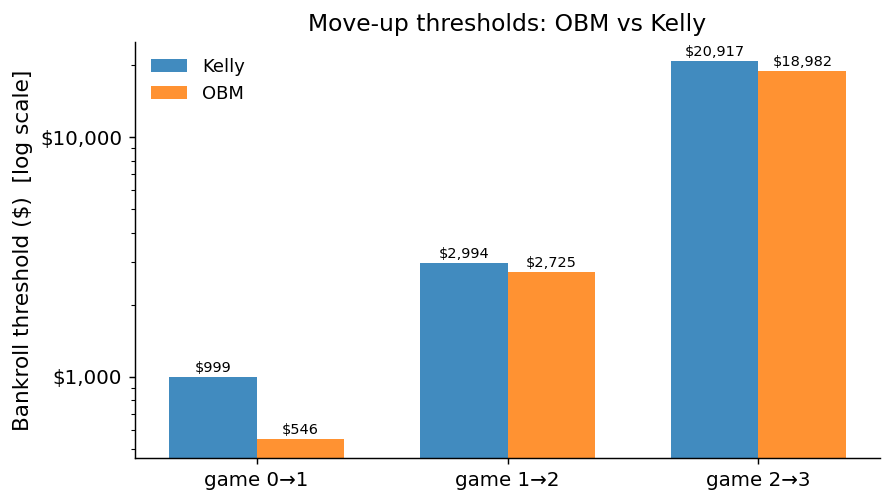


Transition             Kelly         OBM   OBM/Kelly
----------------------------------------------------
  game 0 → game 1     $     999  $     546       0.55x
  game 1 → game 2     $   2,994  $   2,725       0.91x
  game 2 → game 3     $  20,917  $  18,982       0.91x


In [7]:
import matplotlib.patches as mpatches

transitions = [f"game {n-1}→{n}" for n in range(1, N)]
x_pos = np.arange(len(transitions))
bar_w = 0.35

kelly_vals = [thresh_kelly[n] for n in range(1, N)]
obm_vals   = [thresh_obm[n]   for n in range(1, N)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_pos - bar_w / 2, kelly_vals, bar_w, color="#1f77b4", alpha=0.85, label="Kelly")
ax.bar(x_pos + bar_w / 2, obm_vals,   bar_w, color="#ff7f0e", alpha=0.85, label="OBM")

# annotate bar tops
for i, (k, o) in enumerate(zip(kelly_vals, obm_vals)):
    ax.text(i - bar_w / 2, k * 1.02, f"${k:,.0f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + bar_w / 2, o * 1.02, f"${o:,.0f}", ha="center", va="bottom", fontsize=8)

ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(transitions)
ax.set_ylabel("Bankroll threshold ($)  [log scale]")
ax.set_title("Move-up thresholds: OBM vs Kelly")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(FIG_DIR / "obm_vs_kelly_thresholds.png", bbox_inches="tight")
plt.show()

# ── summary table ────────────────────────────────────────────────────────────
print(f"\n{'Transition':<16}  {'Kelly':>10}  {'OBM':>10}  {'OBM/Kelly':>10}")
print("-" * 52)
for n in range(1, N):
    ratio = thresh_obm[n] / thresh_kelly[n]
    print(f"  game {n-1} → game {n}     ${thresh_kelly[n]:>8,.0f}  ${thresh_obm[n]:>8,.0f}  {ratio:>9.2f}x")